# 3_analise.ipynb

Este notebook consome a **camada Silver** (dados já limpos e tipados no PostgreSQL)
para responder às perguntas de negócio do projeto e construir a **camada Gold**
(uma tabela agregada + uma view, criadas via `JOIN` + `GROUP BY`).

**Estrutura do notebook:**
1. Conexão com o banco e helpers de consulta/gráfico
2. 3 perguntas de negócio direto sobre a Silver (consulta + tabela + gráfico)
3. Construção da camada Gold agregada (tabela `gold_resumo_orgao` + view `gold_vw_resumo_orgao`)
4. Mais 4 perguntas de negócio (consulta + tabela + gráfico), totalizando as 7 perguntas do enunciado
5. Conclusões e insights

In [1]:
import urllib.parse
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine

import banco
import config

pd.set_option("display.max_colwidth", 60)

# Conexão psycopg2 (banco.py) -> usada para comandos DDL (CREATE TABLE/VIEW)
conexao = banco.conectar()

_cfg = config.POSTGRES_CONFIG
_senha_segura = urllib.parse.quote_plus(_cfg["password"])
_url = (
    f"postgresql+psycopg2://{_cfg['user']}:{_senha_segura}"
    f"@{_cfg['host']}:{_cfg['port']}/{_cfg['dbname']}"
)
engine = create_engine(_url)
print("Conectado ao PostgreSQL com sucesso.")


Conectado ao PostgreSQL com sucesso.


In [2]:
def consultar(sql, parametros=None):
    """Executa uma consulta SQL e retorna um DataFrame pandas (via engine SQLAlchemy)."""
    return pd.read_sql(sql, engine, params=parametros)

def formatar_numero_br(valor, casas_decimais=2):
    """Formata um numero no padrao brasileiro: ponto como separador de milhar e virgula como decimal."""
    texto = f"{valor:,.{casas_decimais}f}"
    texto = texto.replace(",", "TEMP").replace(".", ",").replace("TEMP", ".")
    return texto

def grafico_barras_horizontal(df, coluna_y, coluna_x, titulo, rotulo_y, rotulo_x, cor="#2E86AB"):
    fig, eixo = plt.subplots(figsize=(10, 6))
    barras = eixo.barh(df[coluna_y].astype(str), df[coluna_x], color=cor)
    eixo.set_title(titulo, fontsize=13, fontweight="bold")
    eixo.set_xlabel(rotulo_x)
    eixo.set_ylabel(rotulo_y)
    eixo.invert_yaxis()
    for barra in barras:
        largura = barra.get_width()
        eixo.annotate(formatar_numero_br(largura, 2), 
                      (largura, barra.get_y() + barra.get_height() / 2),
                      ha="left", va="center", fontsize=10, xytext=(5, 0),
                      textcoords="offset points")
    eixo.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: formatar_numero_br(x, 0)))
    plt.tight_layout()
    plt.show()


### Pergunta 1 — Quais os 5 órgãos com maior custo total?
Considera o `valor_total` calculado na camada Silver (`silver_viagem`), somado por
`nome_orgao_superior`.

,nome_orgao_superior,custo_total,qtd_viagens
0,Ministério da Justiça e Segurança Pública,4.857482e+08,75324
1,Ministério da Defesa,1.545959e+08,61369
2,Ministério da Educação,1.097598e+08,64757
3,Ministério do Meio Ambiente e Mudança do Clima,4.930060e+07,19291
4,Ministério da Previdência Social,4.023618e+07,8129


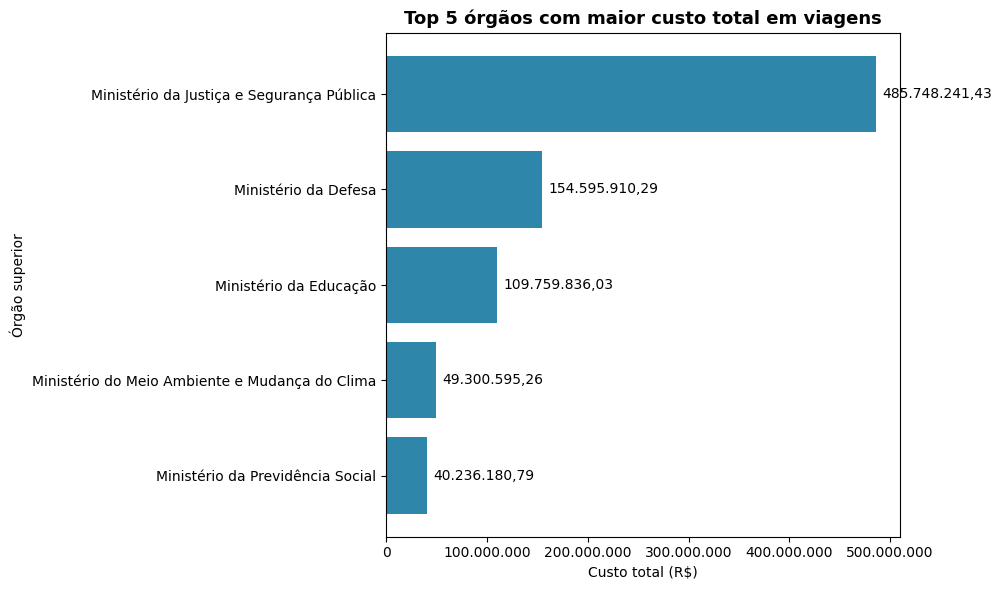

In [3]:
sql_q1 = """
    SELECT nome_orgao_superior,
           SUM(valor_total) AS custo_total,
           COUNT(*) AS qtd_viagens
    FROM silver_viagem
    WHERE nome_orgao_superior IS NOT NULL
      AND situacao = 'Realizada' -- Garante que o gasto de fato ocorreu
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""
df_q1 = consultar(sql_q1)
display(df_q1)

grafico_barras_horizontal(
    df_q1,
    coluna_y="nome_orgao_superior",
    coluna_x="custo_total",
    titulo="Top 5 órgãos com maior custo total em viagens",
    rotulo_y="Órgão superior",
    rotulo_x="Custo total (R$)",
)


### Pergunta 2 — Os 3 destinos com maior custo médio por viagem?

Abaixo analise deste cenário sob duas óticas de interpretação:

#### Abordagem A: Agrupamento por Roteiro/Combinação Completa de Destinos
Analisa a string `destinos` de forma integral. Não isola cidades, mas identifica quais os roteiros combinados geram os maiores custos médios estruturais.

--- Abordagem A: Combinação Completa de Destinos ---


,combinacao_destinos,qtd_viagens,custo_medio
0,"Pequim/China, Xangai/China",9,57683.82
1,"Copenhague/Dinamarca, Oslo/Noruega",7,48406.34
2,Ahmedabad/Índia,10,36394.34


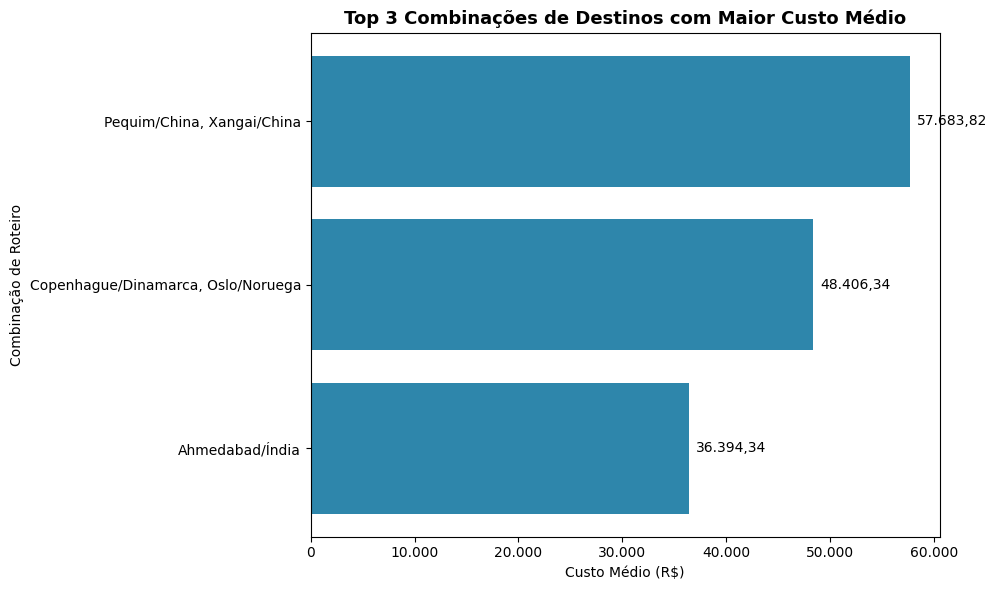

In [4]:
sql_q2_a = """
SELECT destinos AS combinacao_destinos,
           COUNT(id_viagem) AS qtd_viagens,
           ROUND(AVG(valor_total), 2) AS custo_medio
    FROM silver_viagem
    WHERE destinos IS NOT NULL 
      AND destinos != 'Sem informação' 
      AND destinos != ''
      AND situacao = 'Realizada' -- Apenas viagens concluídas
      AND duracao_dias <= 30  -- Remover outliers que distorcem a média (missões longas)
    GROUP BY destinos
    HAVING COUNT(id_viagem) > 5
    ORDER BY custo_medio DESC
    LIMIT 3
"""
df_q2_a = consultar(sql_q2_a)
print("--- Abordagem A: Combinação Completa de Destinos ---")
display(df_q2_a)

grafico_barras_horizontal(
    df_q2_a, 
    coluna_y="combinacao_destinos", 
    coluna_x="custo_medio", 
    titulo="Top 3 Combinações de Destinos com Maior Custo Médio", 
    rotulo_y="Combinação de Roteiro", 
    rotulo_x="Custo Médio (R$)",
    cor="#2E86AB"
)


In [5]:
# Consulta (Detalhes)

sql_detalhes_combinacoes = """
    SELECT id_viagem,
           destinos AS combinacao_destinos,
           valor_total,
           duracao_dias,
           nome_viajante,
           nome_orgao_superior,
           motivo
    FROM silver_viagem
    WHERE destinos IS NOT NULL 
      
      -- Filtra apenas as viagens que pertencem ao Top 3 calculado dinamicamente
      AND destinos IN (
          SELECT combinacao_destinos 
          FROM ( """ + sql_q2_a + """ ) AS rotas_top3
      )
      
    ORDER BY destinos, valor_total DESC;
"""

# Executa e exibe a listagem detalhada
df_detalhes_combinacoes = consultar(sql_detalhes_combinacoes)

print(f"\\nTotal de viagens detalhadas nas top 3 combinações: {len(df_detalhes_combinacoes)}")
display(df_detalhes_combinacoes)

\nTotal de viagens detalhadas nas top 3 combinações: 26


,id_viagem,combinacao_destinos,valor_total,duracao_dias,nome_viajante,nome_orgao_superior,motivo
0,0000000000020804707,Ahmedabad/Índia,69539.21,25,PEDRO HENRIQUE SILVANO DA SILVA,Ministério da Saúde,Realizar inspeções sequenciais para verificação de reque...
1,0000000000020803544,Ahmedabad/Índia,53902.36,24,MARCIO PESSOA COSTA PINHO,Ministério da Saúde,Realizar inspeções sequenciadas para verificação de requ...
2,0000000000020898562,Ahmedabad/Índia,32704.50,9,MARCOS FERNANDO GALVES DA SILVA,Ministério da Saúde,Realizar inspeção de BPF para Medicamentos na empresa EM...
3,0000000000020818126,Ahmedabad/Índia,32016.04,10,ROBELMA FRANCE DE OLIVEIRA GOMES,Ministério da Saúde,Realização de inspeção em Boas Práticas de Fabricação na...
4,0000000000020831431,Ahmedabad/Índia,32016.04,10,DIANA DE SOUZA GARCIA NUNES,Ministério da Saúde,Realização de inspeção em Boas Práticas de Fabricação na...
5,0000000000020887726,Ahmedabad/Índia,31658.79,9,KATIA ANDREA DOMINGOS DE MORAIS,Ministério da Saúde,Realizar inspeção de BPF para Medicamentos na empresa EM...
6,0000000000020672970,Ahmedabad/Índia,31270.54,9,BENEFRAN JUNIO DA SILVA BEZERRA,Ministério da Saúde,Realizar inspeção de Boas Práticas de Fabricação na empr...
7,0000000000020665705,Ahmedabad/Índia,31176.32,9,FRANCISCO ALEXANDRE SHAMMASS DE MANCILHA,Ministério da Saúde,Realizar inspeção de Boas Práticas de Fabricação na empr...
8,0000000000020757343,Ahmedabad/Índia,24829.78,10,MILAY RORATO DE OLIVEIRA RIOS,Ministério da Saúde,Realizar inspeção para fins de certificação de boas prát...
9,0000000000020755838,Ahmedabad/Índia,24829.78,10,ANDRESSA SIMOES COSTA SOUTO,Ministério da Saúde,Realizar inspeção para fins de certificação de boas prát...


#### Abordagem B: Destino Único Validado via Camada Relacional (`silver_trecho`)
Filtra apenas viagens de destino exclusivo (sem vírgulas em `destinos`) e realiza um `JOIN` com a tabela `silver_trecho` para extrair de forma limpa a cidade de origem e destino diretamente das colunas tipadas da modelagem.

--- Abordagem B: Destino Único (Validado com 1 Trecho Exato) ---


,origem_cidade,destino_exclusivo,qtd_viagens,custo_medio,rota
0,Brasília,Berlim,6,12088.05,Brasília ➔ Berlim
1,São Paulo,Hyderabad,6,6977.59,São Paulo ➔ Hyderabad
2,Houston,Lisboa,8,5995.30,Houston ➔ Lisboa


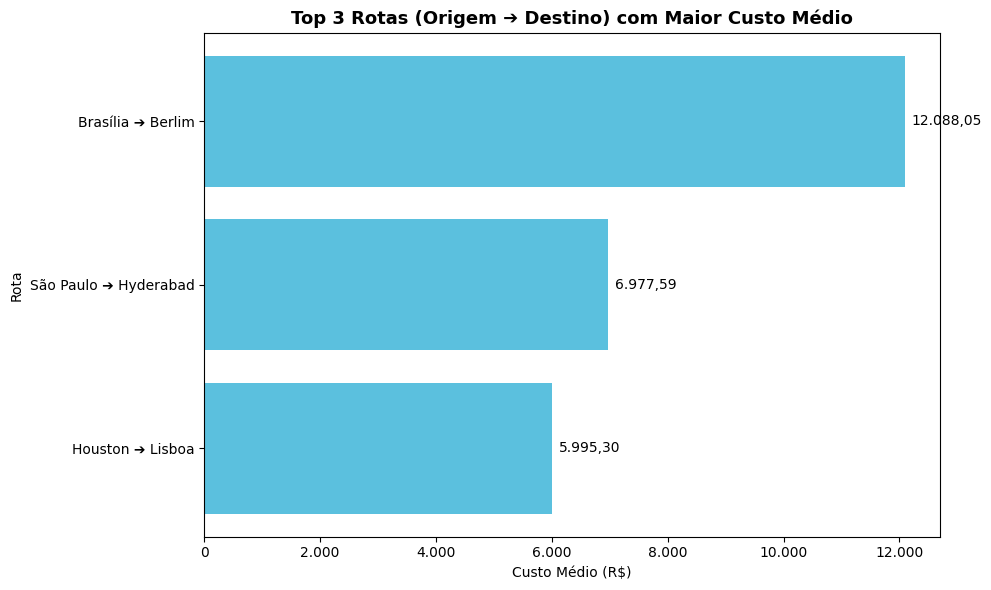

In [6]:
sql_q2_b = """
SELECT t.origem_cidade,
        t.destino_cidade AS destino_exclusivo,
        COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
        ROUND(AVG(v.valor_total), 2) AS custo_medio
    FROM silver_viagem v
    INNER JOIN silver_trecho t ON v.id_viagem = t.id_viagem
    WHERE v.destinos IS NOT NULL
      AND v.destinos != 'Sem informação'
      AND v.destinos NOT LIKE '%%,%%'
      AND situacao = 'Realizada' -- Apenas viagens concluídas
      AND v.duracao_dias <= 30 -- Remover outliers que distorcem a média (missões longas)
      -- Garante que a viagem tem estritamente apenas 1 trecho cadastrado
      AND v.id_viagem IN (
          SELECT id_viagem 
          FROM silver_trecho 
          GROUP BY id_viagem 
          HAVING COUNT(*) = 1
      )
    GROUP BY t.origem_cidade, t.destino_cidade
    HAVING COUNT(DISTINCT v.id_viagem) > 5
    ORDER BY custo_medio DESC
    LIMIT 3
"""
df_q2_b = consultar(sql_q2_b)
df_q2_b["rota"] = df_q2_b["origem_cidade"] + " ➔ " + df_q2_b["destino_exclusivo"]

print("--- Abordagem B: Destino Único (Validado com 1 Trecho Exato) ---")
display(df_q2_b)

# Gerar o gráfico usando a nova coluna 'rota'
grafico_barras_horizontal(
    df_q2_b, 
    coluna_y="rota",
    coluna_x="custo_medio", 
    titulo="Top 3 Rotas (Origem ➔ Destino) com Maior Custo Médio", 
    rotulo_y="Rota", 
    rotulo_x="Custo Médio (R$)",
    cor="#5BC0DE"
)

In [7]:
# Consulta (Detalhes)
sql_detalhes_rotas = """
    SELECT v.id_viagem,
           t.origem_cidade,
           t.destino_cidade,
           v.valor_total,
           v.duracao_dias,
           v.nome_viajante,
           v.nome_orgao_superior,
           v.motivo
    FROM silver_viagem v
    INNER JOIN silver_trecho t ON v.id_viagem = t.id_viagem
    WHERE v.destinos IS NOT NULL 
      AND v.destinos != 'Sem informação'
      AND v.destinos NOT LIKE '%%,%%'
      
      -- Garante que tem apenas 1 trecho cadastrado
      AND v.id_viagem IN (
          SELECT id_viagem 
          FROM silver_trecho 
          GROUP BY id_viagem 
          HAVING COUNT(*) = 1
      )
      
      -- Injeção dinâmica da variável via concatenação segura de strings
      AND (t.origem_cidade, t.destino_cidade) IN (
          SELECT origem_cidade, destino_exclusivo 
          FROM ( """ + sql_q2_b + """ ) AS rotas_top3
      )
      
    ORDER BY t.origem_cidade, v.valor_total DESC;
"""

# Executa e exibe a listagem das 32 viagens detalhadas
df_detalhes_rotas = consultar(sql_detalhes_rotas)

# Criando a coluna de rota para facilitar a leitura visual
df_detalhes_rotas["rota"] = df_detalhes_rotas["origem_cidade"] + " ➔ " + df_detalhes_rotas["destino_cidade"]

# Reorganizando as colunas para a rota ficar no começo
colunas = ["id_viagem", "rota", "valor_total", "duracao_dias", "nome_viajante", "nome_orgao_superior", "motivo"]
df_detalhes_rotas = df_detalhes_rotas[colunas]

print(f"\\nTotal de viagens detalhadas nas top 3 rotas: {len(df_detalhes_rotas)}")
display(df_detalhes_rotas)

\nTotal de viagens detalhadas nas top 3 rotas: 20


,id_viagem,rota,valor_total,duracao_dias,nome_viajante,nome_orgao_superior,motivo
0,0000000000020983727,Brasília ➔ Berlim,18095.96,2,RAFAEL SANDOR PILTZ,Ministério da Defesa,Movimentação de militar por início de missão no exterior.
1,0000000000020984374,Brasília ➔ Berlim,14428.83,2,RAFAELA HEIDRICH PILTZ,Ministério da Defesa,Viagem da dependente para acompanhar o militar em movime...
2,0000000000020984056,Brasília ➔ Berlim,14428.83,2,PEDRO HENRIQUE HEIDRICH PILTZ,Ministério da Defesa,Viagem do dependente para acompanhar militar em moviment...
3,0000000000020714244,Brasília ➔ Berlim,9420.38,2,ANDRE PINTO PACHECO,Ministério das Relações Exteriores,"Remoção SERE - Berlim (E), BS nº 244 de 19/12/2024."
4,0000000000020738871,Brasília ➔ Berlim,9176.71,2,PAULO MARCIO NEVES RODRIGUES,Ministério das Relações Exteriores,"Remoção da SERE p/ Brasemb Berlim, conforme BS 95/24."
5,0000000000020725465,Brasília ➔ Berlim,6977.58,2,BERNARDO ANDRADE VAZ DE FARIA PEREIRA,Ministério das Relações Exteriores,"Remoção da SERE p/ Brasemb Berlim, conforme BS 244/24."
6,0000000000020825171,Houston ➔ Lisboa,8832.88,6,SILAS AIMORE DA LUZ BASTOS,Ministério da Defesa,Realizar Missão Presidencial no Exterior.
7,0000000000020825167,Houston ➔ Lisboa,7232.87,6,THIAGO VASCONCELOS SILVA,Ministério da Defesa,Realizar Missão Presidencial no Exterior.
8,0000000000020825165,Houston ➔ Lisboa,6611.90,6,LUCAS SILVA DE ATAIDE,Ministério da Defesa,Realizar Missão Presidencial no Exterior.
9,0000000000020825169,Houston ➔ Lisboa,6611.90,6,LUIZ PAULO DE SOUSA E CRUZ,Ministério da Defesa,Realizar Missão Presidencial no Exterior.


### Pergunta 3 — A viagem de maior duração e seu custo total?
Gráfico de caixa (Boxplot) para lidar com a imensa massa de dados e evidenciar de forma estatística os valores extremos (outliers).

--- A viagem mais longa e seu custo ---


,id_viagem,duracao_dias,valor_total,destinos
0,0000000000020793594,378,120650.0,Informações protegidas por sigilo


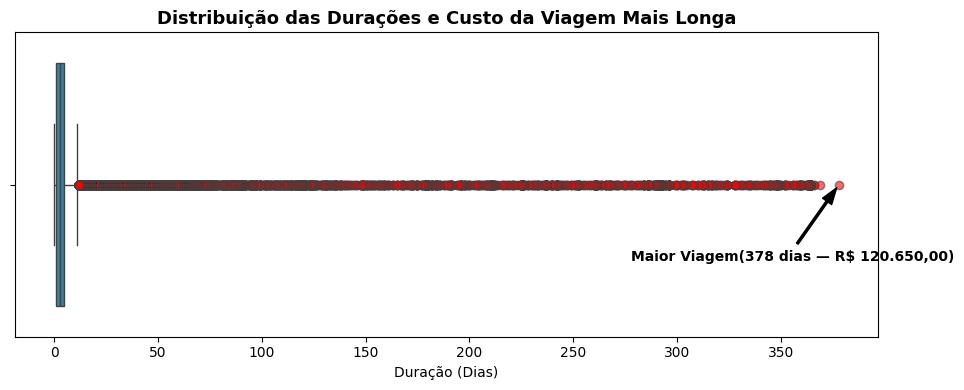

In [8]:
sql_q3 = """
    SELECT id_viagem, duracao_dias, valor_total, destinos
    FROM silver_viagem
    WHERE valor_total > 0 -- REGRA DE NEGÓCIO: Ignorar viagens sem impacto financeiro
          AND situacao = 'Realizada' -- Apenas viagens concluídas
    ORDER BY duracao_dias DESC
"""
df_q3 = consultar(sql_q3)
print("--- A viagem mais longa e seu custo ---")
display(df_q3.head(1))

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_q3['duracao_dias'], color='#2E86AB', 
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.6})

# Extração dinâmica dos valores da viagem líder
maior_duracao = df_q3.iloc[0]['duracao_dias']
custo_maior_viagem = df_q3.iloc[0]['valor_total']

# Formatação do custo para o padrão brasileiro (R$ 1.234,56)
custo_formatado = f"R$ {custo_maior_viagem:,.2f}".replace(",", "v").replace(".", ",").replace("v", ".")

# Apontando dinamicamente para o outlier mostrando Dias e Custo juntos
plt.annotate(f'Maior Viagem({maior_duracao} dias — {custo_formatado})', 
             xy=(maior_duracao, 0), 
             xytext=(maior_duracao - 100, 0.25), # Ajustado para o texto longo não cortar
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, 
             fontweight='bold', 
             color='black')

plt.title('Distribuição das Durações e Custo da Viagem Mais Longa', fontsize=13, fontweight='bold')
plt.xlabel('Duração (Dias)')
plt.tight_layout()
plt.show()


## Construção da Camada Gold
Criação da tabela agregada `gold_resumo_orgao` utilizando a junção (`JOIN`) e agregação.

In [9]:
from sqlalchemy import text
sql_criar_gold = text("""
    DROP VIEW IF EXISTS gold_vw_resumo_orgao;
    DROP TABLE IF EXISTS gold_resumo_orgao;

    CREATE TABLE gold_resumo_orgao AS
    SELECT 
        v.nome_orgao_superior,
        COUNT(DISTINCT v.id_viagem) AS total_viagens,
        SUM(v.valor_total) AS gasto_total_viagens,
        COUNT(DISTINCT p.id_pagamento) AS total_pagamentos,
        SUM(p.valor) AS soma_pagamentos
    FROM silver_viagem v
    LEFT JOIN silver_pagamento p ON v.id_viagem = p.id_viagem
    GROUP BY v.nome_orgao_superior;

    CREATE VIEW gold_vw_resumo_orgao AS 
    SELECT * FROM gold_resumo_orgao;
""")

with engine.begin() as conn:
    conn.execute(sql_criar_gold)
print("Tabela 'gold_resumo_orgao' e VIEW criadas com sucesso na base de dados.")


Tabela 'gold_resumo_orgao' e VIEW criadas com sucesso na base de dados.


### Pergunta 4. Qual o tipo de pagamento com maior valor médio?

In [10]:
sql_q4 = """
    SELECT tipo_pagamento, 
           ROUND(AVG(valor), 2) AS valor_medio
    FROM silver_pagamento
    WHERE tipo_pagamento IS NOT NULL
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
    LIMIT 1;
"""
df_q4 = consultar(sql_q4)
display(df_q4)


,tipo_pagamento,valor_medio
0,DIÁRIAS,2104.1


### Pergunta 5. Qual o meio de transporte mais usado nos trechos?

,meio_transporte,qtd_utilizacoes
0,Veículo Oficial,356215
1,Aéreo,228413
2,Rodoviário,64453
3,Veículo Próprio,37250
4,Inválido,26527


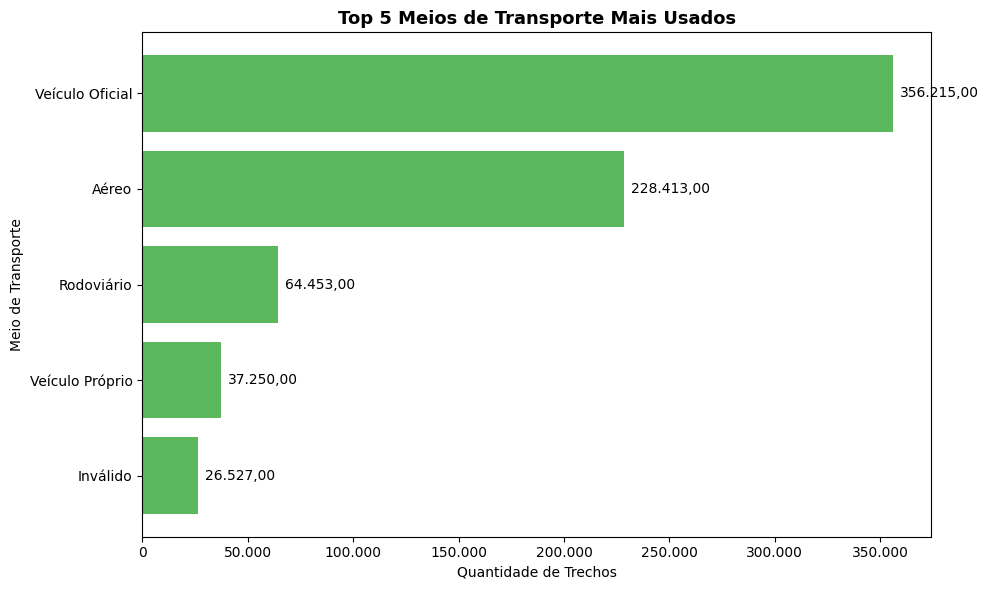

In [11]:
sql_q5 = """
    SELECT meio_transporte, 
           COUNT(*) AS qtd_utilizacoes
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL 
      AND meio_transporte != 'Sem informação'
    GROUP BY meio_transporte
    ORDER BY qtd_utilizacoes DESC
    LIMIT 5;
"""
df_q5 = consultar(sql_q5)
display(df_q5)

grafico_barras_horizontal(
    df_q5, 
    coluna_y="meio_transporte", 
    coluna_x="qtd_utilizacoes", 
    titulo="Top 5 Meios de Transporte Mais Usados", 
    rotulo_y="Meio de Transporte", 
    rotulo_x="Quantidade de Trechos", 
    cor="#5CB85C"
)


### Pergunta 6. Qual UF de destino aparece em mais trechos?

,destino_uf,qtd_trechos
0,Distrito Federal,78539
1,São Paulo,74019
2,Minas Gerais,46181
3,Rio de Janeiro,43409
4,Paraná,39166


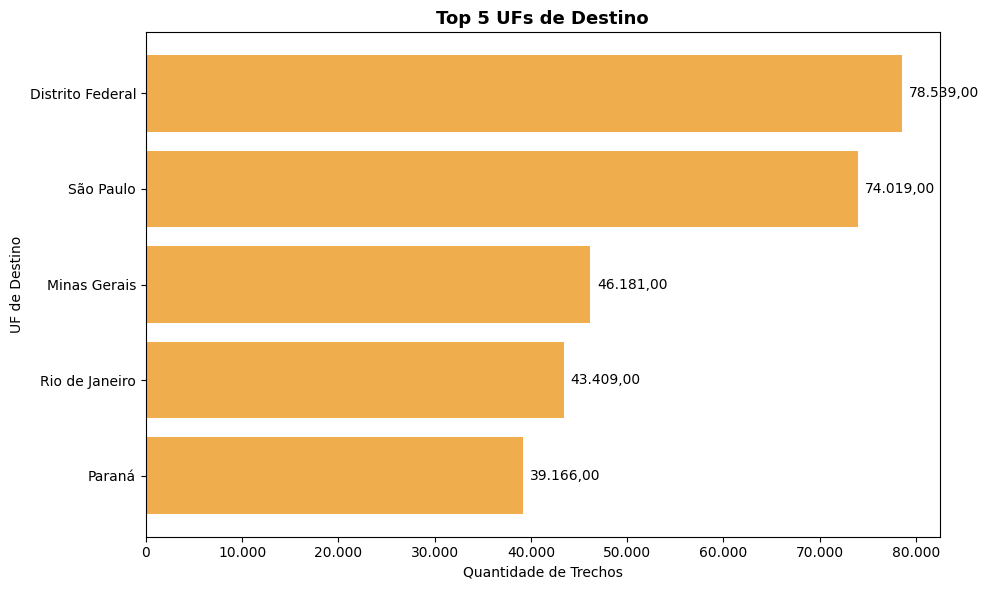

In [12]:
sql_q6 = """
    SELECT destino_uf, 
           COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL 
      AND destino_uf != 'Sem informação'
    GROUP BY destino_uf
    ORDER BY qtd_trechos DESC
    LIMIT 5;
"""
df_q6 = consultar(sql_q6)
display(df_q6)

grafico_barras_horizontal(
    df_q6, 
    coluna_y="destino_uf", 
    coluna_x="qtd_trechos", 
    titulo="Top 5 UFs de Destino", 
    rotulo_y="UF de Destino", 
    rotulo_x="Quantidade de Trechos", 
    cor="#F0AD4E"
)


### Pergunta 7 — Qual órgão pagou mais no total?

,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,2.784810e+08
1,Sigiloso,2.004836e+08
2,Comando da Aeronáutica,8.176914e+07
3,Instituto Nacional do Seguro Social,3.742760e+07
4,Comando do Exército,3.687264e+07


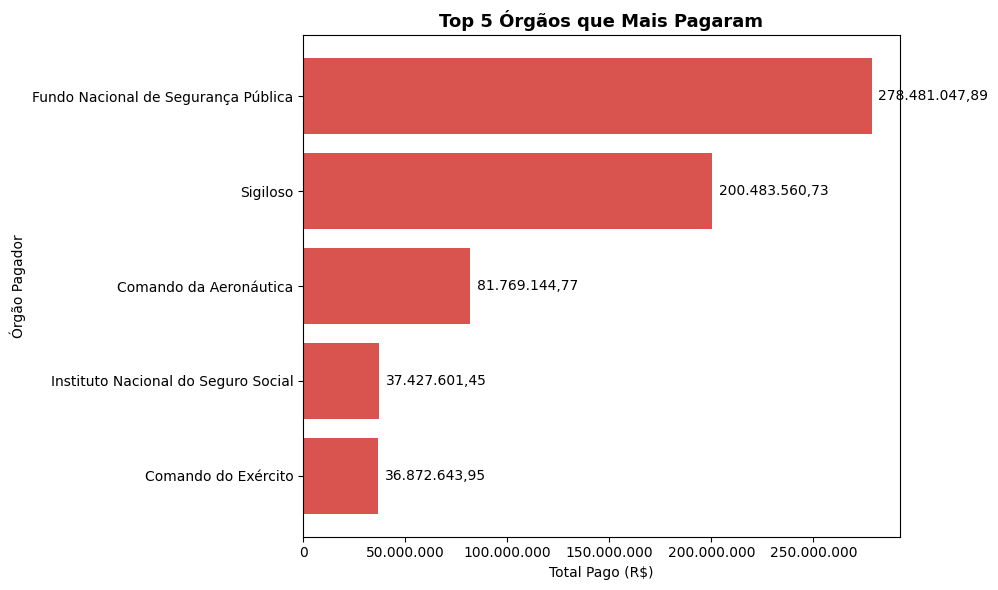

In [13]:
sql_q7 = """
    SELECT nome_orgao_pagador, 
           SUM(valor) AS total_pago
    FROM silver_pagamento
    WHERE nome_orgao_pagador IS NOT NULL 
      AND nome_orgao_pagador != 'Sem informação'
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 5;
"""
df_q7 = consultar(sql_q7)
display(df_q7)

grafico_barras_horizontal(
    df_q7, 
    coluna_y="nome_orgao_pagador", 
    coluna_x="total_pago", 
    titulo="Top 5 Órgãos que Mais Pagaram", 
    rotulo_y="Órgão Pagador", 
    rotulo_x="Total Pago (R$)", 
    cor="#D9534F"
)
